In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
import joblib

In [2]:
df=pd.read_csv("cleaned_data.csv")
X=df[["POT","OVA","Age","Attacking","Defending","Power","Movement","Goalkeeping","Mentality","Skill","Club","Best Position","Height","Weight","Preferred Foot"]].copy()
Y=df.Value_log.copy()

In [3]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
X_train = pd.get_dummies(X_train, columns=["Preferred Foot","Best Position"], drop_first=True)
X_test = pd.get_dummies(X_test, columns=["Preferred Foot","Best Position"], drop_first=True)

In [4]:
from sklearn.preprocessing import TargetEncoder

encoder = TargetEncoder(random_state=42)
X_train["Club_enc"] = encoder.fit_transform(X_train[["Club"]], Y_train)
X_test["Club_enc"] = encoder.transform(X_test[["Club"]])
X_train.drop(["Club"],axis=1,inplace=True)
X_test.drop(["Club"],axis=1,inplace=True)

C:\Users\parth\anaconda3\envs\testenv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


In [5]:
X_train.head()

,POT,OVA,Age,Attacking,Defending,Power,Movement,Goalkeeping,Mentality,Skill,...,Best Position_LB,Best Position_LM,Best Position_LW,Best Position_LWB,Best Position_RB,Best Position_RM,Best Position_RW,Best Position_RWB,Best Position_ST,Club_enc
9189,66,66,30,264,187,322,343,44,278,316,...,False,False,False,False,False,False,False,False,False,13.218164
12864,63,63,29,257,105,301,400,52,238,272,...,False,False,False,False,False,False,False,False,False,12.950828
16626,69,58,20,219,171,273,335,48,243,267,...,False,False,False,False,False,False,False,False,False,13.514189
12209,67,63,24,270,168,276,400,39,278,302,...,False,False,False,False,False,True,False,False,False,13.552673
9360,66,66,28,90,35,199,215,318,123,97,...,False,False,False,False,False,False,False,False,False,13.435816


In [6]:
lr=LinearRegression()
lr.fit(X_train,Y_train)
np.mean(cross_val_score(lr,X_train,Y_train, scoring="neg_mean_absolute_error",cv=5))

np.float64(-0.45531502594107887)

In [7]:
rf=RandomForestRegressor()
np.mean(cross_val_score(rf,X_train,Y_train, scoring="neg_mean_absolute_error",cv=5))

np.float64(-0.0374340775893129)

In [8]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators": [100,200, 300, 500, 700],
    "max_depth": [None, 10, 20, 30],
    "min_samples_leaf": [1, 2, 5, 10]
}

random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_grid,
    n_iter=25,              # only tests 25 random combinations, not all of them
    scoring="neg_mean_absolute_error",
    cv=5,
    n_jobs=-1,
    random_state=42,        # makes which 25 combos get picked reproducible
    verbose=2
)

random_search.fit(X_train, Y_train)

print("Best params:", random_search.best_params_)
print("Best CV MAE (log scale):", -random_search.best_score_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best params: {'n_estimators': 700, 'min_samples_leaf': 1, 'max_depth': 30}
Best CV MAE (log scale): 0.03721145696975618


In [9]:
best_rf = random_search.best_estimator_

In [10]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
best_rf = random_search.best_estimator_   

y_pred_log = best_rf.predict(X_test)

r2 = r2_score(Y_test, y_pred_log)

y_test_real = np.expm1(Y_test)
y_pred_real = np.expm1(y_pred_log)

mae = mean_absolute_error(y_test_real, y_pred_real)
rmse = root_mean_squared_error(y_test_real, y_pred_real)

print(f"R²:   {r2:.4f}")
print(f"MAE:  €{mae:,.0f}")
print(f"RMSE: €{rmse:,.0f}")

R²:   0.9776
MAE:  €128,437
RMSE: €776,692


Text(0.5, 1.0, 'Predicted vs Actual Value — test set')

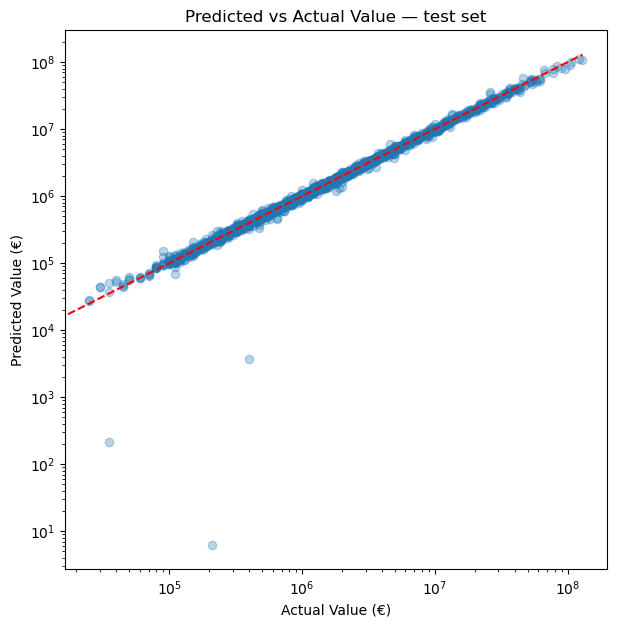

In [11]:
plt.figure(figsize=(7,7))
plt.scatter(y_test_real, y_pred_real, alpha=0.3)
plt.plot([y_test_real.min(), y_test_real.max()], [y_test_real.min(), y_test_real.max()], 'r--')
plt.xlabel("Actual Value (€)")
plt.ylabel("Predicted Value (€)")
plt.xscale("log"); plt.yscale("log")
plt.title("Predicted vs Actual Value — test set")

In [13]:
joblib.dump(best_rf,"Final model")

['Final model']